# The Dark-Pool Ratio — a quantitative teardown 🔬
### Spearman IC (Fisher-z *t*) · quintile long-short · label-shuffle placebo · size-confound control · costs & borrow · monotone effect sweep · seed-robust positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Informed_accumulation_in_the_dark%3F: Unproven](https://img.shields.io/badge/Informed_accumulation_in_the_dark%3F-Unproven-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a stock's **dark-pool ratio** (off-exchange volume share) predicts forward returns.

> ⚠️ **Synthetic-only, and here's why.** No free per-name daily dark-pool-ratio tape exists: FINRA ATS volume is weekly & lagged, off-ATS internalised flow is excluded, clean feeds are paywalled (see [`data.py`](../dark_pool_ratio/data.py)). So there is nothing to certify `REAL`; this is a **machinery proof** on a deterministic world (seed 559), and the tape gap is stated on the Signal axis. Numbers mirror [`docs/results.md`](../docs/results.md); methods in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dark_pool_ratio import data, strategy as st

SEED = 559
# The study is SYNTHETIC-ONLY: no free real dark-pool-ratio tape exists (FINRA ATS is weekly &
# lagged, off-ATS internalised flow is excluded, clean feeds are paywalled). Everything below runs
# on the deterministic synthetic world, offline and reproducible.
REAL = data.fetch_panel(fetch=False)     # empty by construction — documented in data.py
HAVE_REAL = not REAL.empty
NULL_PANEL, _ = data.synthetic_null_panel(seed=SEED)   # the primary cross-section (dpr_alpha = 0)
print("real DPR tape available:", HAVE_REAL, "(none exists on a free stack — synthetic-only study)")
print("null-world synthetic panel:", len(NULL_PANEL), "names, seed", SEED)


real DPR tape available: False (none exists on a free stack — synthetic-only study)
null-world synthetic panel: 300 names, seed 559


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No free real tape (⇒ capped below `REAL`); synthetic null IC **+0.026** (IC-*t* **+0.44**, placebo *p* 0.65); the only lift (raw null IC-*t* +0.77, 25 seeds) is a **size confound** → **-0.19** controlled. |
| **Tradability** | `MIRAGE` | Edge is a confound, panel unbuildable from free data. Null gross 1.28% → net 0.58% (5 bps/leg + 50 bps borrow). |
| **Informed accumulation in the dark?** | `UNPROVEN` | Engine banks a planted effect at IC-*t* +2.32 (still +1.39 netting size) — faithful detector, no tape & ambiguous theory. |

> 💡 In plain words: the detector works (the positive control proves it), but there is no real DPR tape to run it on, and the naive synthetic signal is size in disguise.

## 1 · The claim, steelmanned

Let $D_i$ be firm $i$'s dark-pool ratio and $r_i$ its forward return.

- **H₁ (IC).** $\text{IC} = \text{Spearman}(D, r) > 0$ at *t* ≥ 2 (darker names rank higher in forward return).
- **H₂ (long-short).** $\mathbb{E}[r \mid \text{dark}] - \mathbb{E}[r \mid \text{lit}] > 0$.
- **H₃ (not a confound).** The IC survives controlling for size/liquidity.
- **H₄ (net).** H₁ survives costs and the short-leg borrow.

The decisive obstacle to **H₁** is data: no free daily DPR panel exists, so a robust *t* ≥ 2 on a *real* tape — the only thing that earns `REAL` — cannot be computed. On the synthetic null, **H₁ is not rejected in the folklore's favour** (IC ≈ 0), **H₃ fails for the naive sort** (the apparent lift is size), and **H₄ is moot** (no edge to net).

## 2 · So what? — what rides on each answer

The content is the **why**. Two things sink the folklore before any tape: (a) **theory** — Zhu (2014) argues dark venues attract the *less* informed orders and Comerton-Forde & Putniņš (2015) find the effect of dark share on price discovery is *non-monotone*, so the sign isn't even predicted to be positive; and (b) **confounding** — dark share rises with size and liquidity (Buti-Rindi-Werner), both independent return drivers. This study reuses the IC + placebo + positive-control machinery of [540 Distress-Risk-Anomaly](../../540-distress-risk-anomaly/).

## 3 · How we'd know — the protocol

- **IC.** Spearman rank correlation of $D$ vs $r$; significance via Fisher-z, $t = \tanh^{-1}(\text{IC})\sqrt{n-3}$.
- **Sort.** Quintile tails: long the darkest fifth, short the most-lit fifth; two-sample (Welch) *t* on the spread.
- **Placebo.** Label-shuffle null (2000 perms) on the IC.
- **Confound control.** OLS of $r$ on $D$ *with a size regressor* — the marginal DPR slope beyond size.
- **Frictions.** Round-trip cost per leg + an annual borrow on the lit short.
- **Effect sweep + positive control.** Dial the planted `dpr_alpha` from null up and watch the IC-*t*, averaged over 25 seeds (house rule ≥ 20).

Timing: $D$ is measured over the formation window (public at that close); enter at that close, hold forward — one execution lag, no look-ahead (baked into the generator). The study is synthetic-only because the real daily DPR panel is not reachable for free.

## 4 · The teardown

### 4a · The IC and the sort — H₁ / H₂ (null world)

The Spearman IC with a Fisher-z *t*, the quintile spread with a Welch *t*, and the label-shuffle placebo — on the null world (no effect planted).

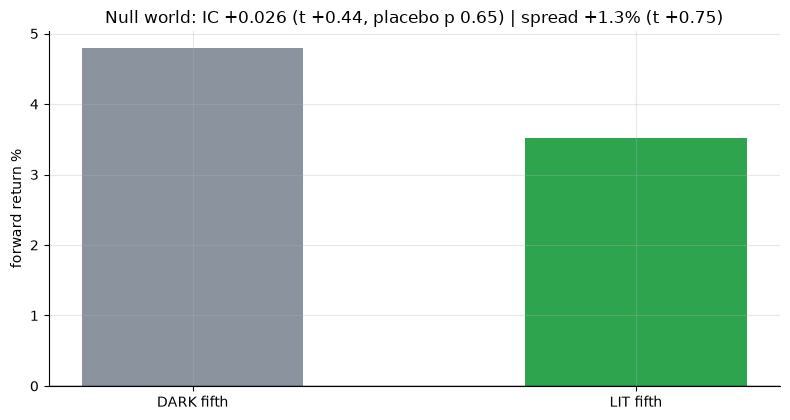

IC +0.026 | IC-t +0.44 | spread +1.3% | LS-t +0.75 | placebo p 0.652


In [2]:
ic = st.information_coefficient(NULL_PANEL)
b = st.bucket_returns(NULL_PANEL, 0.2); ls = st.long_short_tstat(b)
p = st.placebo_pvalue(NULL_PANEL, n_perm=2000, seed=SEED)
icv, ict = ic['ic'], ic['ic_t']
dark_m, lit_m, spr, t = b['dark_mean']*100, b['lit_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['DARK fifth','LIT fifth'], [dark_m, lit_m], color=[GREY, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Null world: IC {icv:+.3f} (t {ict:+.2f}, placebo p {p:.2f}) | spread {spr:+.1f}% (t {t:+.2f})')
plt.tight_layout(); plt.show()
print(f'IC {icv:+.3f} | IC-t {ict:+.2f} | spread {spr:+.1f}% | LS-t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: on the null, **H₁/H₂ are flat** — IC **+0.026** (*t* +0.44), spread **1.28%** (*t* 0.75), placebo *p* = 0.65. The engine correctly reports *nothing* when nothing is planted.

### 4b · The size confound — H₃ (the crux)

Dark share is correlated with size; size drives returns. Average the *raw* IC-*t* over 25 null worlds, then add a size control and re-measure the DPR slope-*t*.

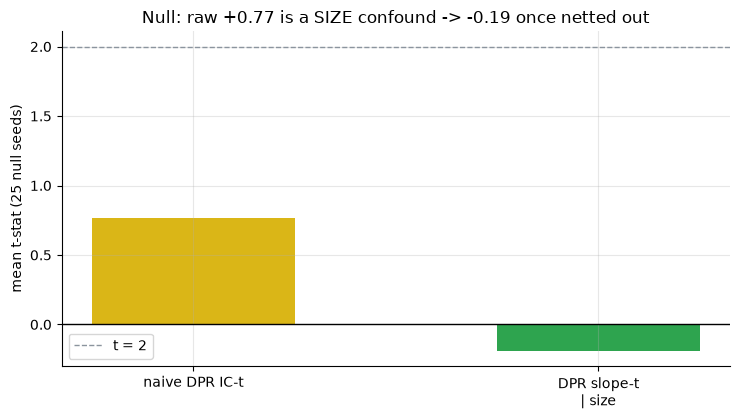

null raw IC-t +0.77 -> controlled slope-t -0.19


In [3]:
def mean_stat(alpha, ctrl, n_seeds=25, base=SEED):
    v=[]
    for s in range(base, base+n_seeds):
        pn,_=data.synthetic_panel(dpr_alpha=alpha, seed=s)
        v.append(st.cross_section_regression(pn, control_size=True)['slope_t'] if ctrl
                 else st.information_coefficient(pn)['ic_t'])
    return float(np.nanmean(v))
raw = mean_stat(0.0, False); ctrl = mean_stat(0.0, True)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['naive DPR IC-t','DPR slope-t\n| size'], [raw, ctrl], color=[AMBER, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2')
ax.set_ylabel('mean t-stat (25 null seeds)'); ax.legend()
ax.set_title(f'Null: raw {raw:+.2f} is a SIZE confound -> {ctrl:+.2f} once netted out')
plt.tight_layout(); plt.show()
print(f'null raw IC-t {raw:+.2f} -> controlled slope-t {ctrl:+.2f}')

> 💡 In plain words: **H₃ fails for the naive sort.** The raw null IC-*t* averages **+0.77** — a *false positive* — but it is entirely the size confound: net size out and the DPR slope-*t* is **-0.19**. Any real DPR study must control for size/liquidity before believing the IC.

### 4c · The effect sweep — the detector responds to truth, not seeds

Dial the planted `dpr_alpha` from null up and watch the mean IC-*t* (25 seeds).

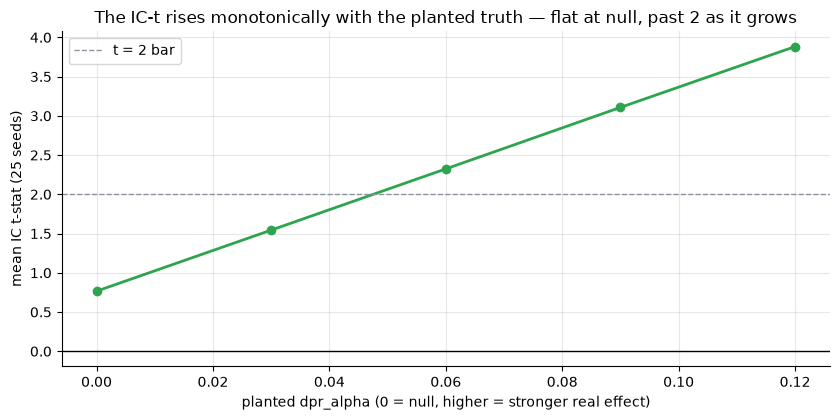

alpha +0.00 -> mean IC +0.044, mean IC-t +0.77
alpha +0.03 -> mean IC +0.089, mean IC-t +1.54
alpha +0.06 -> mean IC +0.134, mean IC-t +2.32
alpha +0.09 -> mean IC +0.178, mean IC-t +3.11
alpha +0.12 -> mean IC +0.221, mean IC-t +3.88


In [4]:
alphas = [w[0] for w in [(0.0, 0.044, 0.77), (0.03, 0.089, 1.54), (0.06, 0.134, 2.32), (0.09, 0.178, 3.11), (0.12, 0.221, 3.88)]]
sweep = st.effect_sweep(data, alphas, n_seeds=25, base_seed=SEED)
xs = [s[0] for s in sweep]; ts = [s[2] for s in sweep]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(xs, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted dpr_alpha (0 = null, higher = stronger real effect)')
ax.set_ylabel('mean IC t-stat (25 seeds)')
ax.set_title('The IC-t rises monotonically with the planted truth — flat at null, past 2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, icv, t in sweep: print(f'alpha {a:+.2f} -> mean IC {icv:+.3f}, mean IC-t {t:+.2f}')

> 💡 In plain words: at the null the IC-*t* is ≈ 0 (the residual +0.77 is the confound); as a *real* effect is planted the IC-*t* climbs monotonically past 2. The detector tracks truth.

## 5 · The verdict

- **Signal `NONE`** — no free real tape (⇒ below `REAL`); synthetic null IC ≈ 0 (*t* +0.44); naive lift is a size confound (+0.77 → -0.19).
- **Tradability `MIRAGE`** — edge is a confound, panel unbuildable from free data; gross 1.28% → net 0.58%.
- **Informed accumulation in the dark? `UNPROVEN`** — faithful engine, no tape, ambiguous theory.

## 6 · Could you trade it? — costs and the borrow

There is no edge to charge costs against; the frictions just deepen the noise-level spread.

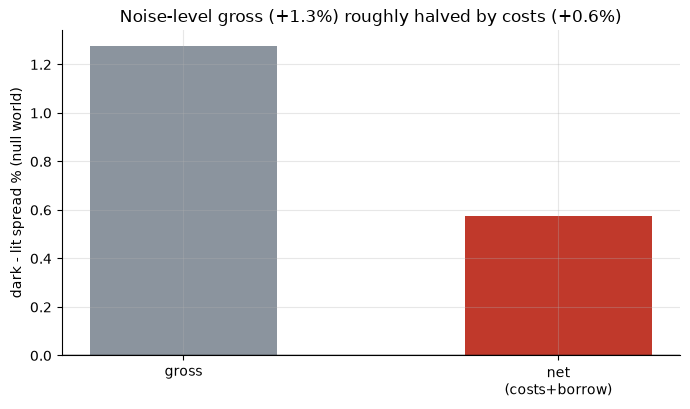

gross +1.28% -> net +0.58% (5 bps/leg + 50 bps borrow, 1y hold)


In [5]:
b = st.bucket_returns(NULL_PANEL, 0.2)
gross = b['spread']*100
net = st.net_spread(b, cost_bps=5.0, borrow_ann_bps=50.0, holding_years=1.0)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[GREY, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('dark - lit spread % (null world)')
ax.set_title(f'Noise-level gross ({gross:+.1f}%) roughly halved by costs ({net:+.1f}%)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f}% -> net {net:+.2f}% (5 bps/leg + 50 bps borrow, 1y hold)')

> 💡 In plain words: at the null the long-dark/short-lit book is ~flat before costs and positive-but-tiny after — no signal to monetise. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real DPR effect (`dpr_alpha > 0`) and confirm the IC-*t* clears 2 — and that the *marginal* effect survives the size control too. Averaged over 25 seeds so no lucky seed can fake it.

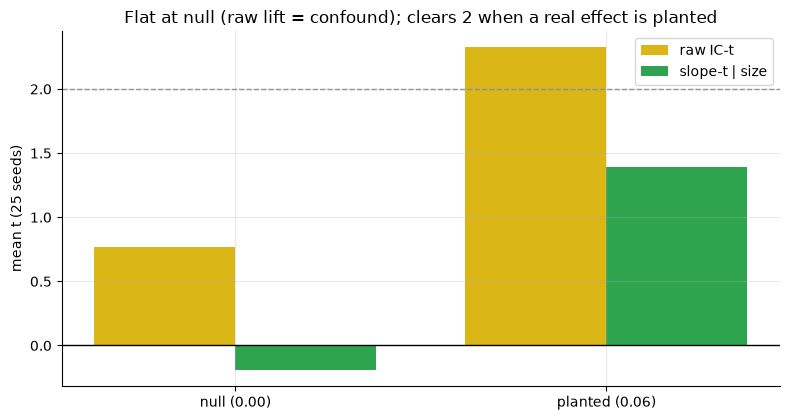

                raw IC-t  slope-t | size
world                                   
null (0.00)         0.77           -0.19
planted (0.06)      2.32            1.39


In [6]:
def mean_stat(alpha, ctrl, n_seeds=25, base=SEED):
    v=[]
    for s in range(base, base+n_seeds):
        pn,_=data.synthetic_panel(dpr_alpha=alpha, seed=s)
        v.append(st.cross_section_regression(pn, control_size=True)['slope_t'] if ctrl
                 else st.information_coefficient(pn)['ic_t'])
    return float(np.nanmean(v))
rows = [('null (0.00)', mean_stat(0.0,False), mean_stat(0.0,True)),
        ('planted (0.06)', mean_stat(0.06,False), mean_stat(0.06,True))]
tab = pd.DataFrame(rows, columns=['world','raw IC-t','slope-t | size']).set_index('world')
x = np.arange(len(tab)); w=0.38
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(x-w/2, tab['raw IC-t'], w, color=AMBER, label='raw IC-t')
ax.bar(x+w/2, tab['slope-t | size'], w, color=GREEN, label='slope-t | size')
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(tab.index); ax.set_ylabel('mean t (25 seeds)'); ax.legend()
ax.set_title('Flat at null (raw lift = confound); clears 2 when a real effect is planted')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

The IC-*t* is ≈ 0 at the null (the +0.77 raw lift is the size confound, which the size control removes to -0.19) and clears 2 (+2.32, still +1.39 controlled) when a real DPR effect is planted — so the engine is a faithful detector. The `NONE` verdict is therefore a statement about **data availability and confounding**, not a broken pipeline. For the close-auction cousin see [376 MOC-Imbalance](../../376-moc-imbalance/); for lit price×volume flow see [418](../../418-money-flow-index/) / [419](../../419-chaikin-money-flow/).